In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error
import shap
import joblib
import os
import mlflow as mf 
import mlflow.sklearn as mfsk

df = pd.read_csv("../data/processed/final_master.csv")
df = pd.DataFrame(df)

pd.set_option('display.max_columns', None)

c:\Users\bubut\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df.head()

,disasterNumber,states_affected,counties_affected,declaration_date,incident_begin,incident_end,ih_declared,ia_declared,pa_declared,hm_declared,tribal_request,fy_declared,incident_duration_days,declaration_lag_days,declaration_month,total_recovery_cost,totalAmountIaApproved,project_count,unique_applicants,unique_damage_categories,total_federal_obligated,pa_cat_A,pa_cat_B,pa_cat_C,pa_cat_D,pa_cat_E,pa_cat_F,pa_cat_G,pa_cat_I,pa_cat_Z,federal_share_ratio,log_target,incident_type_Biological,incident_type_Coastal Storm,incident_type_Earthquake,incident_type_Fire,incident_type_Flood,incident_type_Hurricane,incident_type_Other,incident_type_Severe Ice Storm,incident_type_Severe Storm,incident_type_Snowstorm,incident_type_Tornado,incident_type_Tropical Storm,incident_type_Typhoon,incident_type_Winter Storm
0,1239,1,255,1998-08-26 00:00:00+00:00,1998-08-22 00:00:00+00:00,1998-08-31 00:00:00+00:00,0,1,1,1,0,1998,9,4,8,12112872.98,0.0,276,40,8,7950369.84,13,46,143,3,21,18,29,0,3,0.656357,16.309779,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,1257,1,43,1998-10-21 00:00:00+00:00,1998-10-17 00:00:00+00:00,1998-11-15 00:00:00+00:00,0,1,1,1,0,1999,29,4,10,52186587.22,0.0,1760,187,8,32229051.37,119,228,914,48,200,112,132,0,7,0.617573,17.770336,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,1260,1,33,1999-01-15 00:00:00+00:00,1998-12-23 00:00:00+00:00,1998-12-29 00:00:00+00:00,0,0,1,1,0,1999,6,23,1,11739282.00,0.0,212,90,7,9485830.00,90,52,12,0,7,44,4,0,3,0.808042,16.278451,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,1261,1,12,1999-01-15 00:00:00+00:00,1998-12-23 00:00:00+00:00,1998-12-29 00:00:00+00:00,0,0,1,1,0,1999,6,23,1,6832517.21,0.0,138,73,5,5498755.69,64,43,0,0,5,23,3,0,0,0.804792,15.737204,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,1262,1,24,1999-01-19 00:00:00+00:00,1999-01-17 00:00:00+00:00,1999-02-01 00:00:00+00:00,0,1,1,1,0,1999,15,2,1,16871861.84,0.0,268,53,7,14941466.64,52,52,82,0,45,22,11,0,4,0.885585,16.641158,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [3]:
df.isnull().sum()

disasterNumber                    0
states_affected                   0
counties_affected                 0
declaration_date                  0
incident_begin                    0
incident_end                      0
ih_declared                       0
ia_declared                       0
pa_declared                       0
hm_declared                       0
tribal_request                    0
fy_declared                       0
incident_duration_days            0
declaration_lag_days              0
declaration_month                 0
total_recovery_cost               0
totalAmountIaApproved             0
project_count                     0
unique_applicants                 0
unique_damage_categories          0
total_federal_obligated           0
pa_cat_A                          0
pa_cat_B                          0
pa_cat_C                          0
pa_cat_D                          0
pa_cat_E                          0
pa_cat_F                          0
pa_cat_G                    

In [4]:
########## High Correlated Features#############
# Find pairs of features that are too correlated with each other (threshold 0.95)
corr_matrix = df.select_dtypes(include='number').corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns where correlation > 0.95
high_corr = [col for col in upper.columns if any(upper[col] > 0.90)]

print(high_corr)


['total_federal_obligated', 'incident_type_Biological']


In [5]:
to_drop = ['declaration_date', 'disasterNumber', 'incident_begin', 'incident_end', 'total_federal_obligated', 'total_recovery_cost']
df = df.drop(columns=[col for col in to_drop])

In [6]:
X = df.drop('log_target', axis=1)
y = df['log_target']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Convert predictions and actual values back to dollars
    y_pred_dollars = np.expm1(y_pred)
    y_test_dollars = np.expm1(y_test)
    
    print(f'{name}:')
    print('R2 Score:', r2_score(y_test, y_pred))
    print('Median AE: $', round(median_absolute_error(y_test_dollars, y_pred_dollars), 2))
    print('\n')
    


Random Forest:
R2 Score: 0.8390480068352105
Median AE: $ 3756538.57


Gradient Boosting:
R2 Score: 0.8464433025121207
Median AE: $ 3990504.54




In [7]:
# Random Forest Tuning
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

random_search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,        # tries 50 random combinations instead of all
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_rf.fit(X_train, y_train)

print("Best params:", random_search_rf.best_params_)
print("Best CV R2:", random_search_rf.best_score_)

# Evaluate on test set
y_pred = random_search_rf.best_estimator_.predict(X_test)
print("Test R2:", r2_score(y_test, y_pred))
print("Median AE: $", round(median_absolute_error(np.expm1(y_test), np.expm1(y_pred)), 2))

# Save to MLFlow


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV R2: 0.8311531001880859
Test R2: 0.8332162912372775
Median AE: $ 3646828.84


In [8]:
# Gradient Boosting Tuning
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 5, 7, 10],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2']
}

random_search_gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,        # tries 50 random combinations instead of all
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_gb.fit(X_train, y_train)

print("Best params:", random_search_gb.best_params_)
print("Best CV R2:", random_search_gb.best_score_)

# Evaluate on test set
y_pred = random_search_gb.best_estimator_.predict(X_test)
print("Test R2:", r2_score(y_test, y_pred))
print("Median AE: $", round(median_absolute_error(np.expm1(y_test), np.expm1(y_pred)), 2))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 500, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 5, 'learning_rate': 0.05}
Best CV R2: 0.849939207496163
Test R2: 0.8558491277175716
Median AE: $ 3767501.72


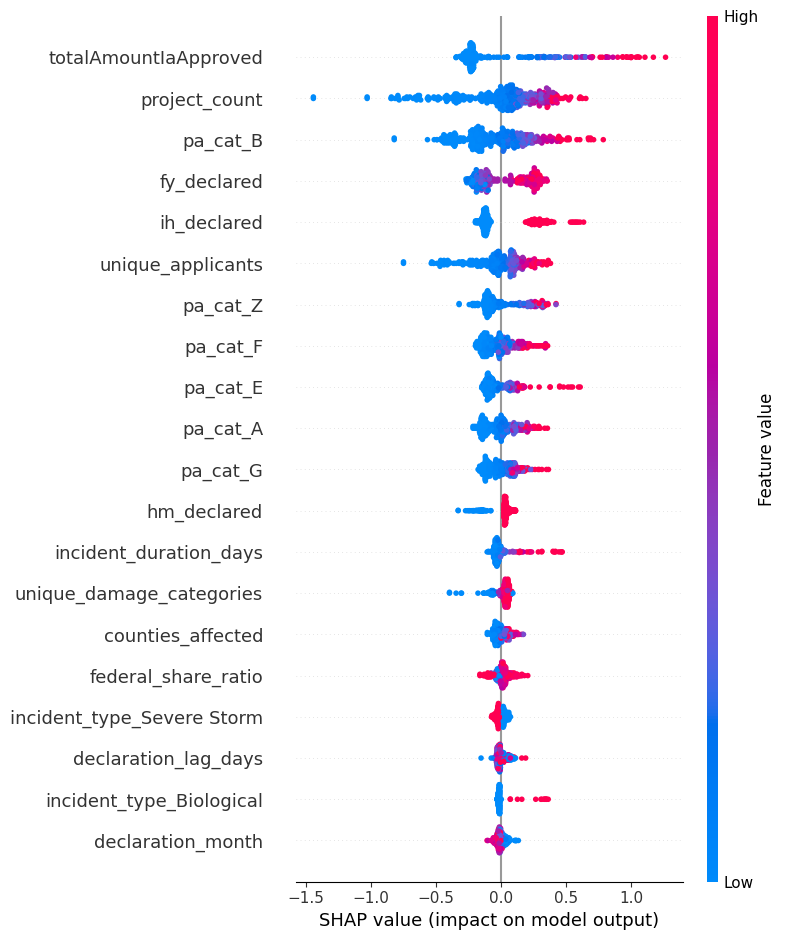

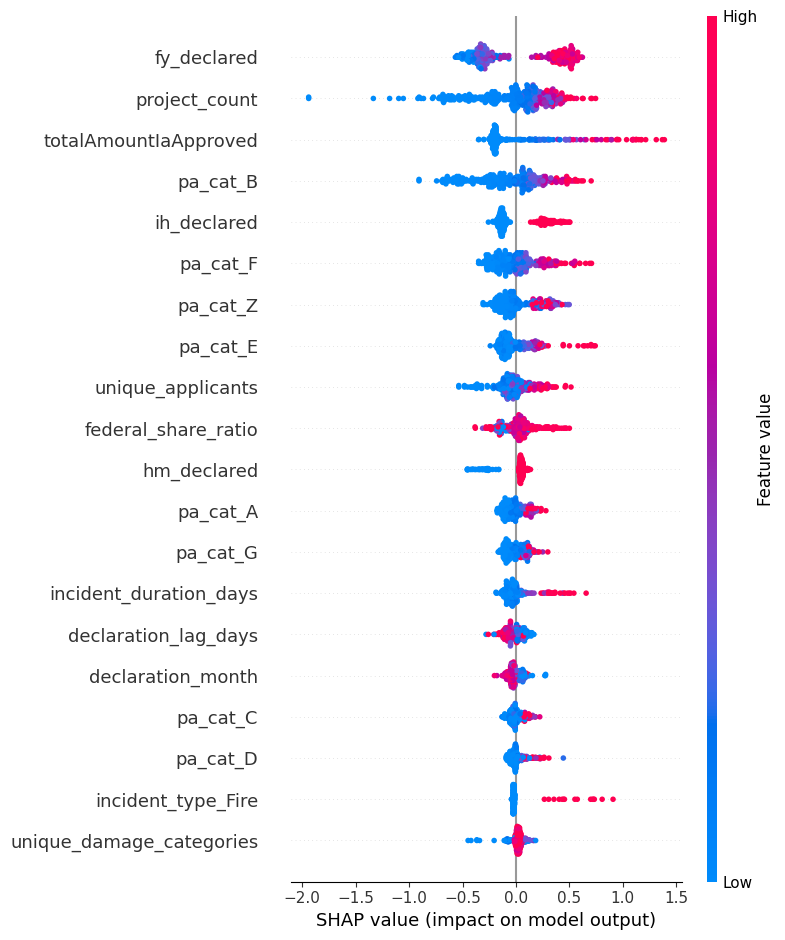

In [9]:
# SHAP values

for model in [random_search_rf, random_search_gb]:
    explainer = shap.TreeExplainer(model.best_estimator_)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test)

In [10]:

os.makedirs('../models', exist_ok=True)

joblib.dump(random_search_rf.best_estimator_,    '../models/fema_rf_model.pkl')
joblib.dump(random_search_gb.best_estimator_,    '../models/fema_gb_model.pkl')

print("All models saved.")

All models saved.


In [11]:


mf.set_experiment("fema-recovery-cost")

models = {
    'Random Forest':     random_search_rf.best_estimator_,
    'Gradient Boosting': random_search_gb.best_estimator_,
}

for name, model in models.items():
    with mf.start_run(run_name=name):

        # ── Log parameters ────────────────────────────────────────────
        mf.log_params(model.get_params())

        # ── Log metrics ───────────────────────────────────────────────
        y_pred         = model.predict(X_test)
        y_pred_dollars = np.expm1(y_pred)
        y_test_dollars = np.expm1(y_test)

        mf.log_metric("r2",        r2_score(y_test, y_pred))
        mf.log_metric("mae",       mean_absolute_error(y_test, y_pred))
        mf.log_metric("rmse",      np.sqrt(mean_squared_error(y_test, y_pred)))
        mf.log_metric("median_ae", median_absolute_error(y_test_dollars, y_pred_dollars))

        # ── Log model ─────────────────────────────────────────────────
        mfsk.log_model(model, artifact_path=name.replace(' ', '_'))

        # ── Log SHAP plot (tree models only) ──────────────────────────
        if name in ['Random Forest', 'Gradient Boosting']:
            explainer  = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test)

            fig, ax = plt.subplots()
            shap.summary_plot(shap_values, X_test, show=False)
            plt.tight_layout()
            mf.log_figure(fig, f"shap_summary_{name.replace(' ', '_')}.png")
            plt.close()

        print(f"Logged: {name}")

2026/04/05 20:59:55 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/04/05 20:59:55 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/04/05 20:59:55 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/04/05 20:59:55 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/04/05 20:59:55 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/04/05 20:59:55 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/04/05 20:59:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/05 20:59:55 INFO mlflow.store.db.utils: Updating database tables
2026/04/05 20:59:55 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/04/05 20:59:55 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/04/05 20:59:55 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/04/05 20:5

Logged: Random Forest


c:\Users\bubut\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Logged: Gradient Boosting


In [12]:
import joblib
import json

# Save feature columns
feature_columns = X.columns.tolist()
with open('../models/feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

# Save incident type categories so API knows all possible values
incident_type_cols = [col for col in X.columns if col.startswith('incident_type_')]
with open('../models/incident_type_cols.json', 'w') as f:
    json.dump(incident_type_cols, f)

print("Saved feature columns:", feature_columns)
print("Saved incident type cols:", incident_type_cols)

pa_cat_cols = [col for col in X.columns if col.startswith('pa_cat_')]
with open('../models/pa_cat_cols.json', 'w') as f:
    json.dump(pa_cat_cols, f)

print("Saved pa_cat cols:", pa_cat_cols)

Saved feature columns: ['states_affected', 'counties_affected', 'ih_declared', 'ia_declared', 'pa_declared', 'hm_declared', 'tribal_request', 'fy_declared', 'incident_duration_days', 'declaration_lag_days', 'declaration_month', 'totalAmountIaApproved', 'project_count', 'unique_applicants', 'unique_damage_categories', 'pa_cat_A', 'pa_cat_B', 'pa_cat_C', 'pa_cat_D', 'pa_cat_E', 'pa_cat_F', 'pa_cat_G', 'pa_cat_I', 'pa_cat_Z', 'federal_share_ratio', 'incident_type_Biological', 'incident_type_Coastal Storm', 'incident_type_Earthquake', 'incident_type_Fire', 'incident_type_Flood', 'incident_type_Hurricane', 'incident_type_Other', 'incident_type_Severe Ice Storm', 'incident_type_Severe Storm', 'incident_type_Snowstorm', 'incident_type_Tornado', 'incident_type_Tropical Storm', 'incident_type_Typhoon', 'incident_type_Winter Storm']
Saved incident type cols: ['incident_type_Biological', 'incident_type_Coastal Storm', 'incident_type_Earthquake', 'incident_type_Fire', 'incident_type_Flood', 'incid

In [13]:
df.columns

# Columns
# Index(['states_affected', 'counties_affected', 'ih_declared', 'ia_declared',
    #    'pa_declared', 'hm_declared', 'tribal_request', 'fy_declared',
    #    'incident_duration_days', 'declaration_lag_days', 'declaration_month',
    #    'totalObligatedAmountPa', 'log_target', 'incident_type_Coastal Storm',
    #    'incident_type_Earthquake', 'incident_type_Fire', 'incident_type_Flood',
    #    'incident_type_Hurricane', 'incident_type_Mud/Landslide',
    #    'incident_type_Other', 'incident_type_Severe Ice Storm',
    #    'incident_type_Severe Storm', 'incident_type_Snowstorm',
    #    'incident_type_Tornado', 'incident_type_Tropical Storm',
    #    'incident_type_Typhoon', 'incident_type_Winter Storm'],
    #   dtype='object')

# Each column and one line explanation
# states_affected - Number of states affected by the disaster
# counties_affected - Number of counties affected by the disaster
# ih_declared - Whether Individual Assistance was declared
# ia_declared - Whether Public Assistance was declared
# pa_declared - Whether Public Assistance was declared
# hm_declared - Whether Hazard Mitigation Assistance was declared
# tribal_request - Whether a tribal request was made
# fy_declared - Fiscal year of disaster declaration
# incident_duration_days - Duration of the disaster in days
# declaration_lag_days - Lag between disaster declaration and incident begin
# declaration_month - Month of disaster declaration
# log_target - Logarithm of the target variable
# incident_type_Coastal Storm - Whether the disaster was a coastal storm
# incident_type_Earthquake - Whether the disaster was an earthquake
# incident_type_Fire - Whether the disaster was a fire
# incident_type_Flood - Whether the disaster was a flood
# incident_type_Hurricane - Whether the disaster was a hurricane
# incident_type_Mud/Landslide - Whether the disaster was a mud/landslide
# incident_type_Other - Whether the disaster was of other type
# incident_type_Severe Ice Storm - Whether the disaster was a severe ice storm
# incident_type_Severe Storm - Whether the disaster was a severe storm
# incident_type_Snowstorm - Whether the disaster was a snowstorm
# incident_type_Tornado - Whether the disaster was a tornado
# incident_type_Tropical Storm - Whether the disaster was a tropical storm
# incident_type_Typhoon - Whether the disaster was a typhoon
# incident_type_Winter Storm - Whether the disaster was a winter storm
# pa_cat is 

Index(['states_affected', 'counties_affected', 'ih_declared', 'ia_declared',
       'pa_declared', 'hm_declared', 'tribal_request', 'fy_declared',
       'incident_duration_days', 'declaration_lag_days', 'declaration_month',
       'totalAmountIaApproved', 'project_count', 'unique_applicants',
       'unique_damage_categories', 'pa_cat_A', 'pa_cat_B', 'pa_cat_C',
       'pa_cat_D', 'pa_cat_E', 'pa_cat_F', 'pa_cat_G', 'pa_cat_I', 'pa_cat_Z',
       'federal_share_ratio', 'log_target', 'incident_type_Biological',
       'incident_type_Coastal Storm', 'incident_type_Earthquake',
       'incident_type_Fire', 'incident_type_Flood', 'incident_type_Hurricane',
       'incident_type_Other', 'incident_type_Severe Ice Storm',
       'incident_type_Severe Storm', 'incident_type_Snowstorm',
       'incident_type_Tornado', 'incident_type_Tropical Storm',
       'incident_type_Typhoon', 'incident_type_Winter Storm'],
      dtype='object')